In [9]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
# Now import your modules
import pandas as pd
from src.config import DATABASE_URL
from sqlalchemy import create_engine

In [10]:
engine = create_engine(DATABASE_URL)
df = pd.read_sql("SELECT * FROM smard_market_data ORDER BY timestamp", engine)
df.head()

,timestamp,gen_nuclear,gen_lignite,gen_offshore_wind,gen_hydro,gen_other_conv,gen_other_renew,gen_biomass,gen_onshore_wind,gen_solar,...,cons_pumped_storage,price_de_lu,price_neighbors,price_at,proj_offshore,proj_onshore,proj_solar,proj_other,proj_wind_solar,proj_total
0,2020-05-03 22:00:00+00:00,1625.25,1788.00,132.00,492.25,386.75,49.75,1124.00,404.25,0.0,...,131.00,22.20,17.42,22.20,131.75,547.50,0.0,5800.38,679.25,6479.63
1,2020-05-03 22:15:00+00:00,1624.25,1814.00,135.00,442.25,385.00,49.75,1118.25,415.75,0.0,...,182.25,22.20,NaN,22.20,128.00,549.00,0.0,5802.63,677.00,6479.63
2,2020-05-03 22:30:00+00:00,1603.75,1817.25,140.50,428.50,383.75,49.75,1117.75,403.25,0.0,...,353.00,22.20,NaN,22.20,124.25,550.50,0.0,5804.88,674.75,6479.63
3,2020-05-03 22:45:00+00:00,1602.75,1812.25,148.25,445.50,384.25,49.75,1117.25,396.50,0.0,...,478.50,22.20,NaN,22.20,121.00,552.25,0.0,5806.38,673.25,6479.63
4,2020-05-03 23:00:00+00:00,1608.00,1781.00,145.25,463.00,385.25,49.75,1114.25,399.50,0.0,...,515.50,20.46,16.18,20.46,118.50,554.25,0.0,6041.08,672.75,6713.83


In [11]:
import numpy as np
import pandas as pd
import holidays

def create_day_ahead_features(df):
    """
    Prepares SMARD data for 24-hour block Day-Ahead electricity price forecasting.
    Downsamples all data to 1-hour resolution and enforces strict causal lag structures.
    """
    df = df.copy()

    # Ensure timestamp is datetime format and sorted chronologically
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df = df.sort_values("timestamp")

    # Set timestamp as index to allow clean time-series resampling
    df = df.set_index("timestamp")

    # =========================================================================
    # 1. RESOLUTION ALIGNMENT (Hourly Resampling)
    # =========================================================================
    # German SMARD generation is 15-min, but Day-Ahead prices are hourly.
    # We downsample all metrics to 1-hour intervals using mean aggregation.
    df = df.resample("1h").mean()
    df = df.reset_index()

    # =========================================================================
    # 2. CALENDAR & TEMPORAL FEATURES (Deterministic Future Knowledge)
    # =========================================================================
    df["hour"] = df["timestamp"].dt.hour
    df["dayofweek"] = df["timestamp"].dt.dayofweek
    df["month"] = df["timestamp"].dt.month

    # Weekends exhibit significantly lower industrial demand
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

    # Incorporate German public holidays which mimic weekend demand profiles
    de_holidays = holidays.Germany(years=range(2020, 2030))
    df["is_holiday"] = df["timestamp"].dt.date.astype(str).isin([str(x) for x in de_holidays]).astype(int)

    # Localize to Berlin to capture structural shifts from Daylight Saving Time (DST)
    berlin_time = df["timestamp"].dt.tz_convert("Europe/Berlin")
    # Check if the timezone offset corresponds to DST (UTC+2 for Berlin)
    df["is_dst"] = (berlin_time.apply(lambda x: x.utcoffset().total_seconds()) == 7200).astype(int)

    # =========================================================================
    # 3. CYCLICAL TRANSFORMATIONS
    # =========================================================================
    # Transform temporal features into sine/cosine pairs so the model understands
    # that hour 23 is physically adjacent to hour 0, and December to January.
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # =========================================================================
    # 4. STRUCTURAL FORECAST FEATURES (Known Ahead of Time)
    # =========================================================================
    # For a 24h block model, tomorrow's actual generation is unknown, but SMARD's
    # *projected* renewable generation is published and acts as a direct price driver.
    if "proj_solar" in df.columns and "proj_onshore" in df.columns and "proj_offshore" in df.columns:
        df["total_proj_renewables"] = df["proj_solar"] + df["proj_onshore"] + df["proj_offshore"]
    else:
        # Fallback if specific breakdowns are absent
        df["total_proj_renewables"] = df.get("proj_wind_solar", 0)

    # =========================================================================
    # 5. HISTORICAL OBSERVED FEATURES (Ex-Post Domain Logic)
    # =========================================================================
    # These metrics evaluate what physically occurred on the grid in the past.
    df["actual_renewables_total"] = df.get("gen_solar", 0) + df.get("gen_onshore_wind", 0) + df.get("gen_offshore_wind", 0)
    df["actual_fossil_total"] = df.get("gen_natural_gas", 0) + df.get("gen_hard_coal", 0) + df.get("gen_lignite", 0)

    # Renewable penetration levels highlight risk profiles for negative prices
    df["historical_renewable_penetration"] = (df["actual_renewables_total"] / df["cons_total_grid"].replace(0, np.nan)).fillna(0)

    # =========================================================================
    # 6. CAUSAL LAG ENGINE (Preventing Target & Data Leakage)
    # =========================================================================
    # Since the EPEX Day-Ahead auction occurs at 12:00 PM CET for the next day's 24 hours,
    # we cannot safely use a lag of less than 24 hours for rolling or observed inputs.
    # Lags applied: 24h (yesterday), 48h (two days ago), 168h (same day last week).

    lag_targets = [
        "price_de_lu", "cons_total_grid", "cons_residual",
        "actual_renewables_total", "actual_fossil_total", "price_at"
    ]

    hourly_lags = [24, 48, 168]

    for col in lag_targets:
        if col not in df.columns:
            continue
        for lag in hourly_lags:
            df[f"{col}_lag_{lag}"] = df[col].shift(lag)

    # =========================================================================
    # 7. ROLLING HISTORICAL VOLATILITY & TRENDS
    # =========================================================================
    # Statistical features derived solely from historical data to track trends.
    # Notice we shift the column by 24 hours *before* computing the rolling window
    # to guarantee no leakage of the target day's timeline.
    rolling_windows = {"24h": 24, "168h": 168}

    for col in ["price_de_lu", "cons_residual", "actual_renewables_total"]:
        if col not in df.columns:
            continue

        causal_base = df[col].shift(24)  # Force shift outside the forecast horizon

        for name, window in rolling_windows.items():
            df[f"{col}_roll_mean_{name}"] = causal_base.rolling(window).mean()
            df[f"{col}_roll_std_{name}"] = causal_base.rolling(window).std()

    # =========================================================================
    # 8. HISTORICAL PRICE RAMPS
    # =========================================================================
    # Tracks structural velocity changes in price and grid loading across days.
    for col in ["price_de_lu", "cons_residual"]:
        if col not in df.columns:
            continue
        df[f"{col}_ramp_24h"] = df[col].shift(24).diff(24)

    # =========================================================================
    # 9. MISSING DATA AND TARGET PROTECTION
    # =========================================================================
    # Isolate the target variable to protect it from artificial forward-fills.
    target_col = "price_de_lu"
    target_series = df[target_col].copy()

    # Forward-fill feature variables to handle transient packet losses in API streams
    for col in df.columns:
        if col == "timestamp" or col == target_col:
            continue
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].ffill()

    # Re-attach the untampered target column
    df[target_col] = target_series

    # Drop early initialization rows containing NaN artifacts due to lag dependencies
    df = df.dropna(subset=[f"price_de_lu_lag_168"])

    return df


df_nw = create_day_ahead_features(df)
df_nw.head()

,timestamp,gen_nuclear,gen_lignite,gen_offshore_wind,gen_hydro,gen_other_conv,gen_other_renew,gen_biomass,gen_onshore_wind,gen_solar,...,cons_residual_roll_mean_24h,cons_residual_roll_std_24h,cons_residual_roll_mean_168h,cons_residual_roll_std_168h,actual_renewables_total_roll_mean_24h,actual_renewables_total_roll_std_24h,actual_renewables_total_roll_mean_168h,actual_renewables_total_roll_std_168h,price_de_lu_ramp_24h,cons_residual_ramp_24h
168,2020-05-10 22:00:00+00:00,1256.0625,971.9375,1536.1250,458.2500,385.000,43.9375,1116.1875,4275.6875,0.0000,...,8275.367188,1324.688776,NaN,NaN,2877.565104,2042.038823,NaN,NaN,-0.81,-1305.3125
169,2020-05-10 23:00:00+00:00,1250.9375,960.7500,1514.5000,454.8750,383.250,44.0000,1110.9375,4427.1875,0.0000,...,8230.471354,1330.140828,NaN,NaN,2900.968750,2023.825346,NaN,NaN,-1.31,-1077.5000
170,2020-05-11 00:00:00+00:00,1218.1250,937.2500,1499.7500,453.0000,379.500,43.3125,1102.1875,4588.4375,0.0000,...,8182.046875,1343.163237,NaN,NaN,2924.309896,2004.039433,NaN,NaN,-1.79,-1162.1875
171,2020-05-11 01:00:00+00:00,1220.5625,853.9375,1517.2500,451.9375,380.000,43.6250,1104.6875,4673.7500,0.0000,...,8133.947917,1355.202139,NaN,NaN,2949.640625,1981.054438,NaN,NaN,-2.72,-1154.3750
172,2020-05-11 02:00:00+00:00,1233.7500,865.0000,1527.0625,459.2500,372.875,44.8750,1117.0625,4723.9375,0.0625,...,8088.895833,1362.041956,NaN,NaN,2973.442708,1958.575617,NaN,NaN,-5.57,-1081.2500


In [12]:
df_nw.columns

Index(['timestamp', 'gen_nuclear', 'gen_lignite', 'gen_offshore_wind',
       'gen_hydro', 'gen_other_conv', 'gen_other_renew', 'gen_biomass',
       'gen_onshore_wind', 'gen_solar', 'gen_hard_coal', 'gen_pumped_storage',
       'gen_natural_gas', 'cons_total_grid', 'cons_residual',
       'cons_pumped_storage', 'price_de_lu', 'price_neighbors', 'price_at',
       'proj_offshore', 'proj_onshore', 'proj_solar', 'proj_other',
       'proj_wind_solar', 'proj_total', 'hour', 'dayofweek', 'month',
       'is_weekend', 'is_holiday', 'is_dst', 'hour_sin', 'hour_cos', 'dow_sin',
       'dow_cos', 'month_sin', 'month_cos', 'total_proj_renewables',
       'actual_renewables_total', 'actual_fossil_total',
       'historical_renewable_penetration', 'price_de_lu_lag_24',
       'price_de_lu_lag_48', 'price_de_lu_lag_168', 'cons_total_grid_lag_24',
       'cons_total_grid_lag_48', 'cons_total_grid_lag_168',
       'cons_residual_lag_24', 'cons_residual_lag_48', 'cons_residual_lag_168',
       'actua

## Q1 — Renewable intermittency effect on price
Does higher actual renewable penetration cause lower prices, and is this effect heterogeneous by time of day (i.e., does the "merit order effect" vary — the core question for BESS dispatch optimization)?

Preparing data...
  Rows after prep: 43,680

  Q1 — Merit order: renewable gen → price_de_lu
  Treatment : actual_renewables_total  (normalised σ=1)
  ATE       : -13.5185 €/MWh per σ-increase
  95% CI    : [-14.7037, -12.3333]
  CATE μ    : -14.9168   σ: 15.7968
  CATE range: [-94.5020, 73.1273]

  Top heterogeneity drivers:
        feature  importance
       hour_cos    0.707214
    gen_nuclear    0.128677
      month_cos    0.104569
cons_total_grid    0.024776

  Q2 — Residual load: cons_residual → price_de_lu
  Treatment : cons_residual  (normalised σ=1)
  ATE       : 27.2443 €/MWh per σ-increase
  95% CI    : [18.5111, 35.9775]
  CATE μ    : 29.6782   σ: 54.1094
  CATE range: [-257.7367, 524.0640]

  Top heterogeneity drivers:
              feature  importance
   price_de_lu_lag_24    0.281362
renewable_penetration    0.243177
          gen_nuclear    0.189775
            month_sin    0.088495

  Q3 — AT spillover: price_at → price_de_lu
  Treatment : price_at  (normalised σ=1)
  

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/causal_results.png'

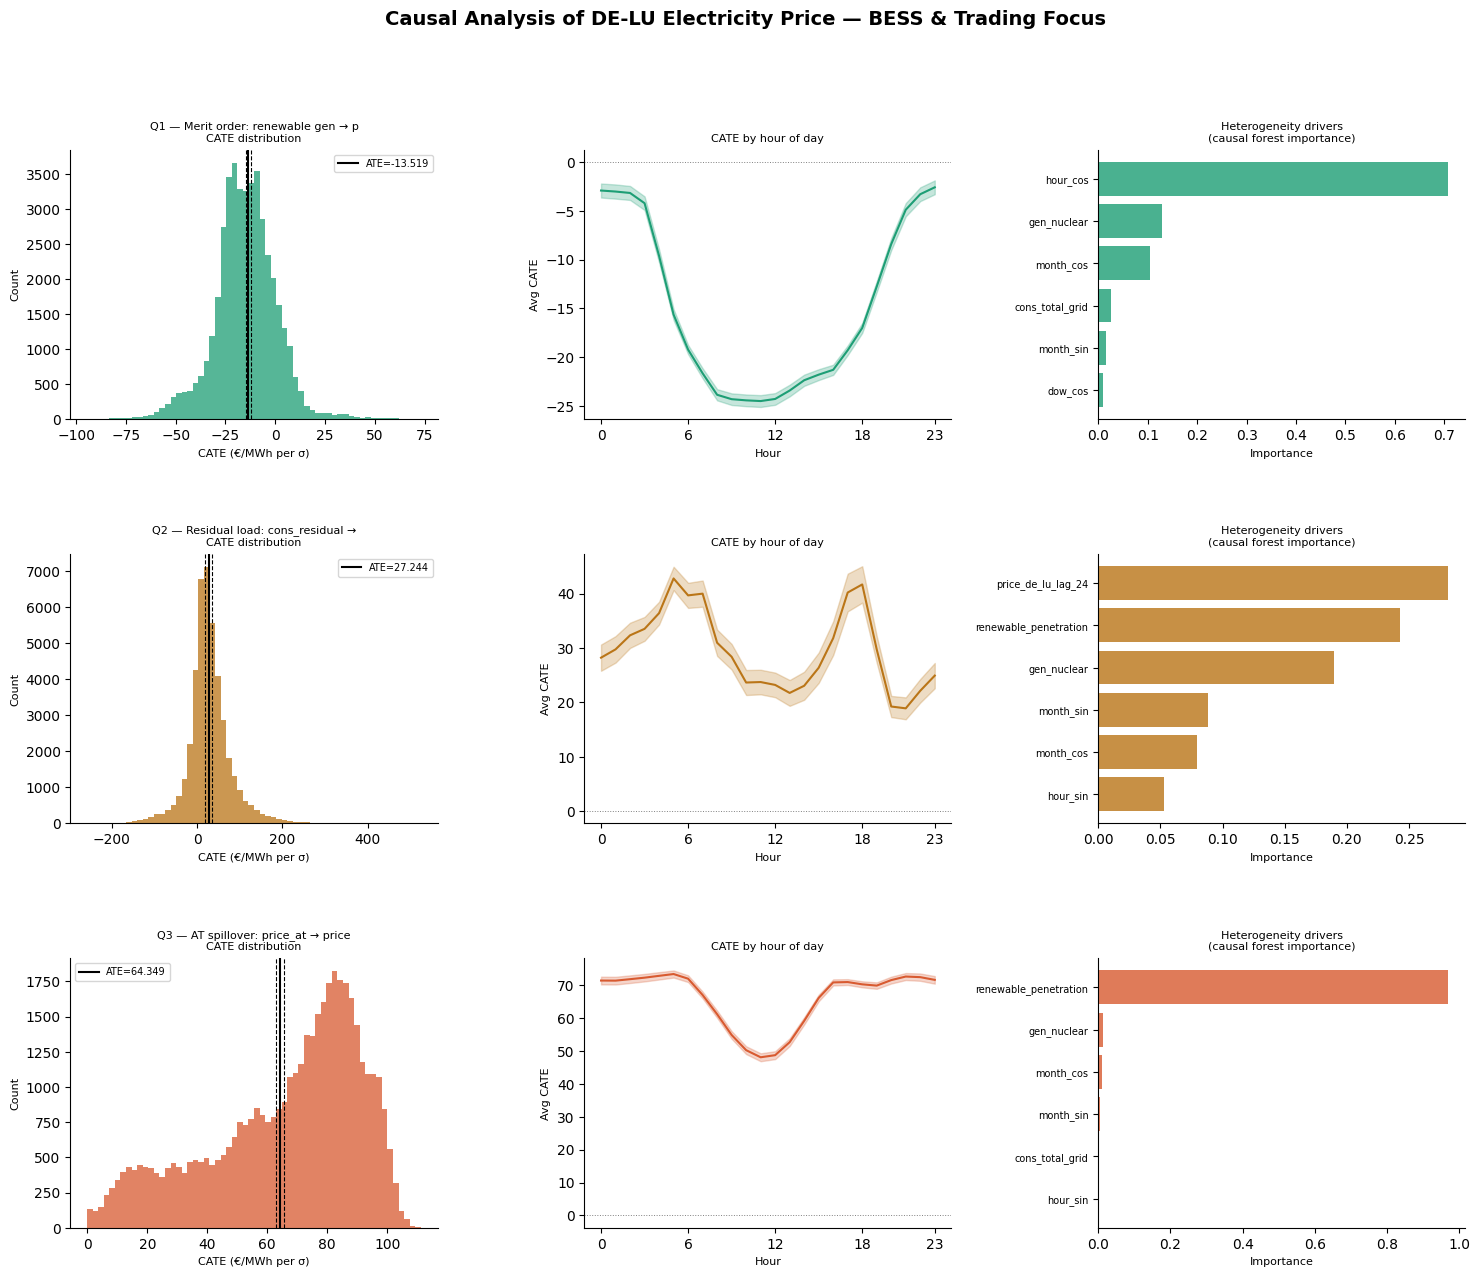

In [17]:
"""
Causal Analysis of DE-LU Electricity Prices
Focus: BESS dispatch optimization & energy trading

3 Questions:
  Q1 — Merit order effect: does renewable penetration causally lower prices?
         Heterogeneity: by hour (day vs night) and weekend
  Q2 — Residual load: does cons_residual causally drive prices beyond forecasts?
         Heterogeneity: by renewable penetration quartile
  Q3 — Cross-border spillover: does price_at causally influence price_de_lu?
         Heterogeneity: by renewable level and hour

Methods: Double ML (DML) for ATE + Causal Forest (GRF) for CATE
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# econml for DML
from econml.dml import LinearDML, CausalForestDML

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
RANDOM_STATE = 42
N_FOLDS      = 5
N_TREES      = 200   # for causal forest
MIN_LEAF     = 20    # min_samples_leaf in causal forest

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size": 10,
})


# ─────────────────────────────────────────────
# 0.  DATA PREP  (assumes df_nw already in memory;
#     adjust path if loading from file)
# ─────────────────────────────────────────────
def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    """Drop rows with NaN in key columns and clip extreme price outliers."""
    key_cols = [
        "price_de_lu", "price_at", "cons_residual",
        "actual_renewables_total", "historical_renewable_penetration",
        "hour", "dayofweek", "month", "is_weekend", "is_holiday",
        "cons_total_grid", "gen_solar", "gen_offshore_wind", "gen_onshore_wind",
        "price_de_lu_lag_24", "price_at_lag_24", "cons_residual_lag_24",
    ]
    df = df.dropna(subset=key_cols).copy()

    # Winsorise price at 1st/99th percentile (handles negative spike / cap)
    lo, hi = df["price_de_lu"].quantile([0.01, 0.99])
    df["price_de_lu"] = df["price_de_lu"].clip(lo, hi)

    # Derived
    df["renewable_penetration"] = (
        df["actual_renewables_total"] / df["cons_total_grid"].replace(0, np.nan)
    ).fillna(df["historical_renewable_penetration"])

    df["peak_hour"]    = df["hour"].between(8, 20).astype(int)
    df["ren_quartile"] = pd.qcut(df["renewable_penetration"], 4,
                                 labels=["Q1_low","Q2","Q3","Q4_high"])
    return df


# ─────────────────────────────────────────────
# 1.  SHARED CONFOUNDERS
# ─────────────────────────────────────────────
BASE_W = [
    # time
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
    "is_weekend", "is_holiday", "is_dst",
    # demand
    "cons_total_grid", "cons_total_grid_lag_24",
    # lags of outcome (to absorb autocorrelation)
    "price_de_lu_lag_24", "price_de_lu_lag_48",
    # generation mix
    "gen_solar", "gen_offshore_wind", "gen_onshore_wind",
    "gen_natural_gas", "gen_hard_coal", "gen_nuclear",
    # projections (information set at forecast time)
    "proj_solar", "proj_onshore", "proj_offshore",
]


# ─────────────────────────────────────────────
# 2.  DML HELPER
# ─────────────────────────────────────────────
def run_dml(
    df: pd.DataFrame,
    treatment: str,
    outcome: str,
    confounders: list,
    heterogeneity_vars: list,
    question_label: str,
) -> dict:
    """
    LinearDML: treatment residual × outcome residual → ATE
    CausalForestDML: heterogeneous treatment effects over X

    Returns dict with model objects + summary stats.
    """
    # Always carry plotting columns alongside model columns
    plot_cols = ["hour", "renewable_penetration", "ren_quartile"]
    plot_cols = [c for c in plot_cols if c in df.columns]
    all_cols  = list(dict.fromkeys(confounders + [treatment, outcome]
                                   + heterogeneity_vars + plot_cols))
    subset = df[all_cols].dropna(subset=confounders + [treatment, outcome]
                                          + heterogeneity_vars)
    Y = subset[outcome].values
    T = subset[treatment].values
    W = subset[confounders].values
    X = subset[heterogeneity_vars].values

    # Normalise T for interpretability
    T_std = T.std()
    T_norm = (T - T.mean()) / (T_std + 1e-8)

    # --- nuisance models ---
    model_y = GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        random_state=RANDOM_STATE
    )
    model_t = GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        random_state=RANDOM_STATE
    )

    # --- Linear DML (ATE) ---
    dml = LinearDML(
        model_y=model_y,
        model_t=model_t,
        cv=N_FOLDS,
        random_state=RANDOM_STATE,
        discrete_treatment=False,
    )
    dml.fit(Y, T_norm, X=X, W=W)
    ate    = dml.ate(X)
    ate_ci = dml.ate_interval(X)

    print(f"\n{'='*55}")
    print(f"  {question_label}")
    print(f"{'='*55}")
    print(f"  Treatment : {treatment}  (normalised σ=1)")
    print(f"  ATE       : {ate:.4f} €/MWh per σ-increase")
    print(f"  95% CI    : [{ate_ci[0]:.4f}, {ate_ci[1]:.4f}]")

    # --- Causal Forest DML (CATE) ---
    cf = CausalForestDML(
        model_y=model_y,
        model_t=model_t,
        n_estimators=N_TREES,
        min_samples_leaf=MIN_LEAF,
        cv=N_FOLDS,
        random_state=RANDOM_STATE,
    )
    cf.fit(Y, T_norm, X=X, W=W)
    cates     = cf.effect(X)
    cate_lb, cate_ub = cf.effect_interval(X)

    print(f"  CATE μ    : {cates.mean():.4f}   σ: {cates.std():.4f}")
    print(f"  CATE range: [{cates.min():.4f}, {cates.max():.4f}]")

    # Feature importance from the causal forest
    feat_imp = cf.feature_importances_
    imp_df   = pd.DataFrame({
        "feature": heterogeneity_vars,
        "importance": feat_imp
    }).sort_values("importance", ascending=False)
    print("\n  Top heterogeneity drivers:")
    print(imp_df.head(4).to_string(index=False))

    return {
        "label":   question_label,
        "treatment": treatment,
        "dml":     dml,
        "cf":      cf,
        "subset":  subset,
        "T_norm":  T_norm,
        "cates":   cates,
        "cate_lb": cate_lb,
        "cate_ub": cate_ub,
        "ate":     ate,
        "ate_ci":  ate_ci,
        "imp_df":  imp_df,
        "X":       X,
        "het_vars": heterogeneity_vars,
    }


# ─────────────────────────────────────────────
# 3.  THREE CAUSAL QUESTIONS
# ─────────────────────────────────────────────

def q1_merit_order(df):
    """
    Treatment : actual_renewables_total  (MWh)
    Outcome   : price_de_lu
    Key het.  : hour_sin/cos (time of day), is_weekend, cons_total_grid
    BESS relevance: dispatch timing — price suppression peaks when solar is high
    """
    confounders = BASE_W + ["cons_residual_lag_24", "price_at_lag_24"]
    # Remove renewables cols from confounders — they're the treatment channel
    confounders = [c for c in confounders if "solar" not in c
                   and "wind" not in c and "renew" not in c]

    het_vars = [
        "hour_sin", "hour_cos",    # time of day effect
        "dow_sin",  "dow_cos",     # day of week
        "is_weekend",
        "cons_total_grid",         # demand level
        "gen_nuclear",             # baseload level
        "month_sin", "month_cos",  # season
    ]
    return run_dml(
        df, "actual_renewables_total", "price_de_lu",
        confounders, het_vars,
        "Q1 — Merit order: renewable gen → price_de_lu"
    )


def q2_residual_load(df):
    """
    Treatment : cons_residual  (net demand after renewables)
    Outcome   : price_de_lu
    Key het.  : renewable_penetration (quartiles), peak_hour, month
    BESS relevance: intraday spread — high residual = high marginal cost = buy signal
    """
    confounders = BASE_W + [
        "actual_renewables_total_lag_24",
        "price_at_lag_24",
        "cons_residual_lag_24",
    ]
    het_vars = [
        "renewable_penetration",   # core moderator
        "peak_hour",
        "hour_sin", "hour_cos",
        "is_weekend",
        "month_sin", "month_cos",
        "gen_nuclear",
        "price_de_lu_lag_24",
    ]
    return run_dml(
        df, "cons_residual", "price_de_lu",
        confounders, het_vars,
        "Q2 — Residual load: cons_residual → price_de_lu"
    )


def q3_at_spillover(df):
    """
    Treatment : price_at  (Austrian spot price)
    Outcome   : price_de_lu
    Key het.  : renewable_penetration, hour, cons_total_grid
    BESS relevance: cross-border arbitrage — AT/DE-LU spread → trading opportunity
    """
    confounders = [c for c in BASE_W if "price_at" not in c] + [
        "cons_residual_lag_24",
        "price_de_lu_lag_48",
        "actual_renewables_total_lag_24",
    ]
    het_vars = [
        "renewable_penetration",
        "hour_sin", "hour_cos",
        "cons_total_grid",
        "is_weekend",
        "is_holiday",
        "month_sin", "month_cos",
        "gen_nuclear",
    ]
    return run_dml(
        df, "price_at", "price_de_lu",
        confounders, het_vars,
        "Q3 — AT spillover: price_at → price_de_lu"
    )


# ─────────────────────────────────────────────
# 4.  VISUALISATION
# ─────────────────────────────────────────────

def plot_results(results: list, df: pd.DataFrame):
    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(
        "Causal Analysis of DE-LU Electricity Price — BESS & Trading Focus",
        fontsize=14, fontweight="bold", y=0.98
    )
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

    colors = ["#1d9e75", "#ba7517", "#d85a30"]

    for row, (res, color) in enumerate(zip(results, colors)):

        # ── col 0: CATE distribution ──────────────────────────────────────
        ax0 = fig.add_subplot(gs[row, 0])
        ax0.hist(res["cates"], bins=60, color=color, alpha=0.75, edgecolor="none")
        ax0.axvline(res["ate"],    color="black",  lw=1.5, label=f"ATE={res['ate']:.3f}")
        ax0.axvline(res["ate_ci"][0], color="black", lw=0.8, ls="--")
        ax0.axvline(res["ate_ci"][1], color="black", lw=0.8, ls="--")
        ax0.set_title(f"{res['label'][:35]}\nCATE distribution", fontsize=8)
        ax0.set_xlabel("CATE (€/MWh per σ)", fontsize=8)
        ax0.set_ylabel("Count", fontsize=8)
        ax0.legend(fontsize=7)

        # ── col 1: CATE by hour ───────────────────────────────────────────
        ax1 = fig.add_subplot(gs[row, 1])
        tmp = res["subset"].copy()
        tmp["cate"] = res["cates"]
        tmp["hour"] = tmp["hour"].astype(int)
        hourly = tmp.groupby("hour")["cate"].agg(["mean", "sem"])
        ax1.plot(hourly.index, hourly["mean"], color=color, lw=1.5)
        ax1.fill_between(
            hourly.index,
            hourly["mean"] - 1.96 * hourly["sem"],
            hourly["mean"] + 1.96 * hourly["sem"],
            alpha=0.25, color=color
        )
        ax1.axhline(0, color="gray", lw=0.7, ls=":")
        ax1.set_title("CATE by hour of day", fontsize=8)
        ax1.set_xlabel("Hour", fontsize=8)
        ax1.set_ylabel("Avg CATE", fontsize=8)
        ax1.set_xticks([0, 6, 12, 18, 23])

        # ── col 2: Feature importance ─────────────────────────────────────
        ax2 = fig.add_subplot(gs[row, 2])
        imp = res["imp_df"].head(6)
        bars = ax2.barh(imp["feature"][::-1], imp["importance"][::-1],
                        color=color, alpha=0.8)
        ax2.set_title("Heterogeneity drivers\n(causal forest importance)", fontsize=8)
        ax2.set_xlabel("Importance", fontsize=8)
        ax2.tick_params(axis="y", labelsize=7)

    plt.savefig("/mnt/user-data/outputs/causal_results.png",
                dpi=150, bbox_inches="tight", facecolor="white")
    print("\n  Plot saved → causal_results.png")
    return fig


def plot_cate_by_renewable_quartile(results, df):
    """Extra plot: CATE heterogeneity across renewable penetration quartiles."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    fig.suptitle("CATE by Renewable Penetration Quartile", fontsize=12, fontweight="bold")
    colors = ["#1d9e75", "#ba7517", "#d85a30"]
    labels = ["Q1\n(low ren.)", "Q2", "Q3", "Q4\n(high ren.)"]

    for ax, res, color in zip(axes, results, colors):
        tmp = res["subset"].copy()
        tmp["cate"] = res["cates"]
        if "renewable_penetration" not in tmp.columns:
            ax.set_title(f"{res['label'][:40]}\n(renewable_penetration not available)", fontsize=8)
            ax.axis("off")
            continue
        tmp["ren_q"] = pd.qcut(tmp["renewable_penetration"], 4, duplicates="drop")
        stats = tmp.groupby("ren_q", observed=False)["cate"].agg(["mean", "sem"])
        xs = range(len(stats))
        ax.bar(xs, stats["mean"], color=color, alpha=0.75)
        ax.errorbar(xs, stats["mean"],
                    yerr=1.96 * stats["sem"],
                    fmt="none", color="black", capsize=4, lw=1)
        ax.set_xticks(list(xs))
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_title(res["label"][:40], fontsize=8)
        ax.set_ylabel("Avg CATE (€/MWh per σ)", fontsize=8)
        ax.axhline(0, color="gray", lw=0.7, ls=":")

    plt.tight_layout()
    plt.savefig("/mnt/user-data/outputs/causal_cate_by_ren_quartile.png",
                dpi=150, bbox_inches="tight", facecolor="white")
    print("  Plot saved → causal_cate_by_ren_quartile.png")


# ─────────────────────────────────────────────
# 5.  MAIN — wire it all together
# ─────────────────────────────────────────────

def run_all(df_nw: pd.DataFrame):
    print("Preparing data...")
    df = prepare_data(df_nw)
    print(f"  Rows after prep: {len(df):,}")

    results = []
    results.append(q1_merit_order(df))
    results.append(q2_residual_load(df))
    results.append(q3_at_spillover(df))

    print("\n\nGenerating plots...")
    plot_results(results, df)
    plot_cate_by_renewable_quartile(results, df)

    return results


# ─────────────────────────────────────────────
# 6.  BESS STRATEGY SUMMARY  (printed after)
# ─────────────────────────────────────────────

def print_bess_insights(results):
    q1, q2, q3 = results
    print("\n" + "="*55)
    print("  BESS & TRADING INSIGHTS")
    print("="*55)
    print(f"""
Q1 – Merit order (renewables → price)
  ATE = {q1['ate']:.3f} €/MWh per σ-increase in renewables
  → Negative ATE confirms merit order effect.
  → Causal forest gives the HOUR where suppression is
    largest — that's when BESS should be CHARGING
    (cheapest power).

Q2 – Residual load (cons_residual → price)
  ATE = {q2['ate']:.3f} €/MWh per σ-increase in residual load
  → Positive ATE = higher residual → higher marginal cost.
  → CATE by renewable quartile shows how much this effect
    shrinks when renewables are abundant — the intraday
    spread opportunity collapses in high-ren periods.

Q3 – AT spillover (price_at → price_de_lu)
  ATE = {q3['ate']:.3f} €/MWh per €1 std-normalised AT move
  → If ATE is close to 1 and CI excludes 0, markets are
    coupled → arbitrage is competed away quickly.
  → Large CATE variance by hour = some hours still offer
    exploitable AT/DE-LU spread for cross-border trading.
""")


# ─────────────────────────────────────────────
# RUN  (call this from your notebook / script)
# ─────────────────────────────────────────────
if __name__ == "__main__":
    # If running standalone, load df_nw here:
    # df_nw = pd.read_parquet("your_data.parquet")
    results = run_all(df_nw)     # df_nw must be in scope
    print_bess_insights(results)

In [ ]:
print_bess_insights(results)